In [1]:
%%capture
!pip uninstall qunum -y
!pip install /Users/matt/qunum

In [8]:
import qunum.numerical as qn
from qunum.jupyter_tools.plotting import PlotIt
from qunum.numerical.physics.quantum.heisenberg.bbgky_truncation.bbgky import BBGKYDecoupling as BBGKY
import os, torch
import time
import tqdm
def mk_obj(N:int, n:int,**kwargs)->BBGKY:
    print(N,n)
    a = dict(Nsteps= int(4500), u0 = 10_000*1e2, tgt_u0 = 5, debug=False, load_data=False, dp = .1, p0 = torch.tensor(1e10), method = 'gaussrk', adaptive_epsilon=5e-3, dt  = 1e-2, adaptive_time_step=True, r0_Rv = 7.5, p_start_f = .1)
    a.update(kwargs)
    print(a)
    return BBGKY(
        N=N, n=n, 
        data_storage_loc=os.path.join('BBGKYSims', f'BBGKY_{N}-{n}'),
        **a
    )

In [20]:
O = mk_obj(10,2, Nsteps = 5_000, renorm = True)

for o in tqdm.tqdm(O):
    pass


10 2
{'Nsteps': 5000, 'u0': 1000000.0, 'tgt_u0': 5, 'debug': False, 'load_data': False, 'dp': 0.1, 'p0': tensor(1.0000e+10), 'method': 'gaussrk', 'adaptive_epsilon': 0.005, 'dt': 0.01, 'adaptive_time_step': True, 'r0_Rv': 7.5, 'p_start_f': 0.1, 'renorm': True}


4999it [00:14, 355.32it/s]


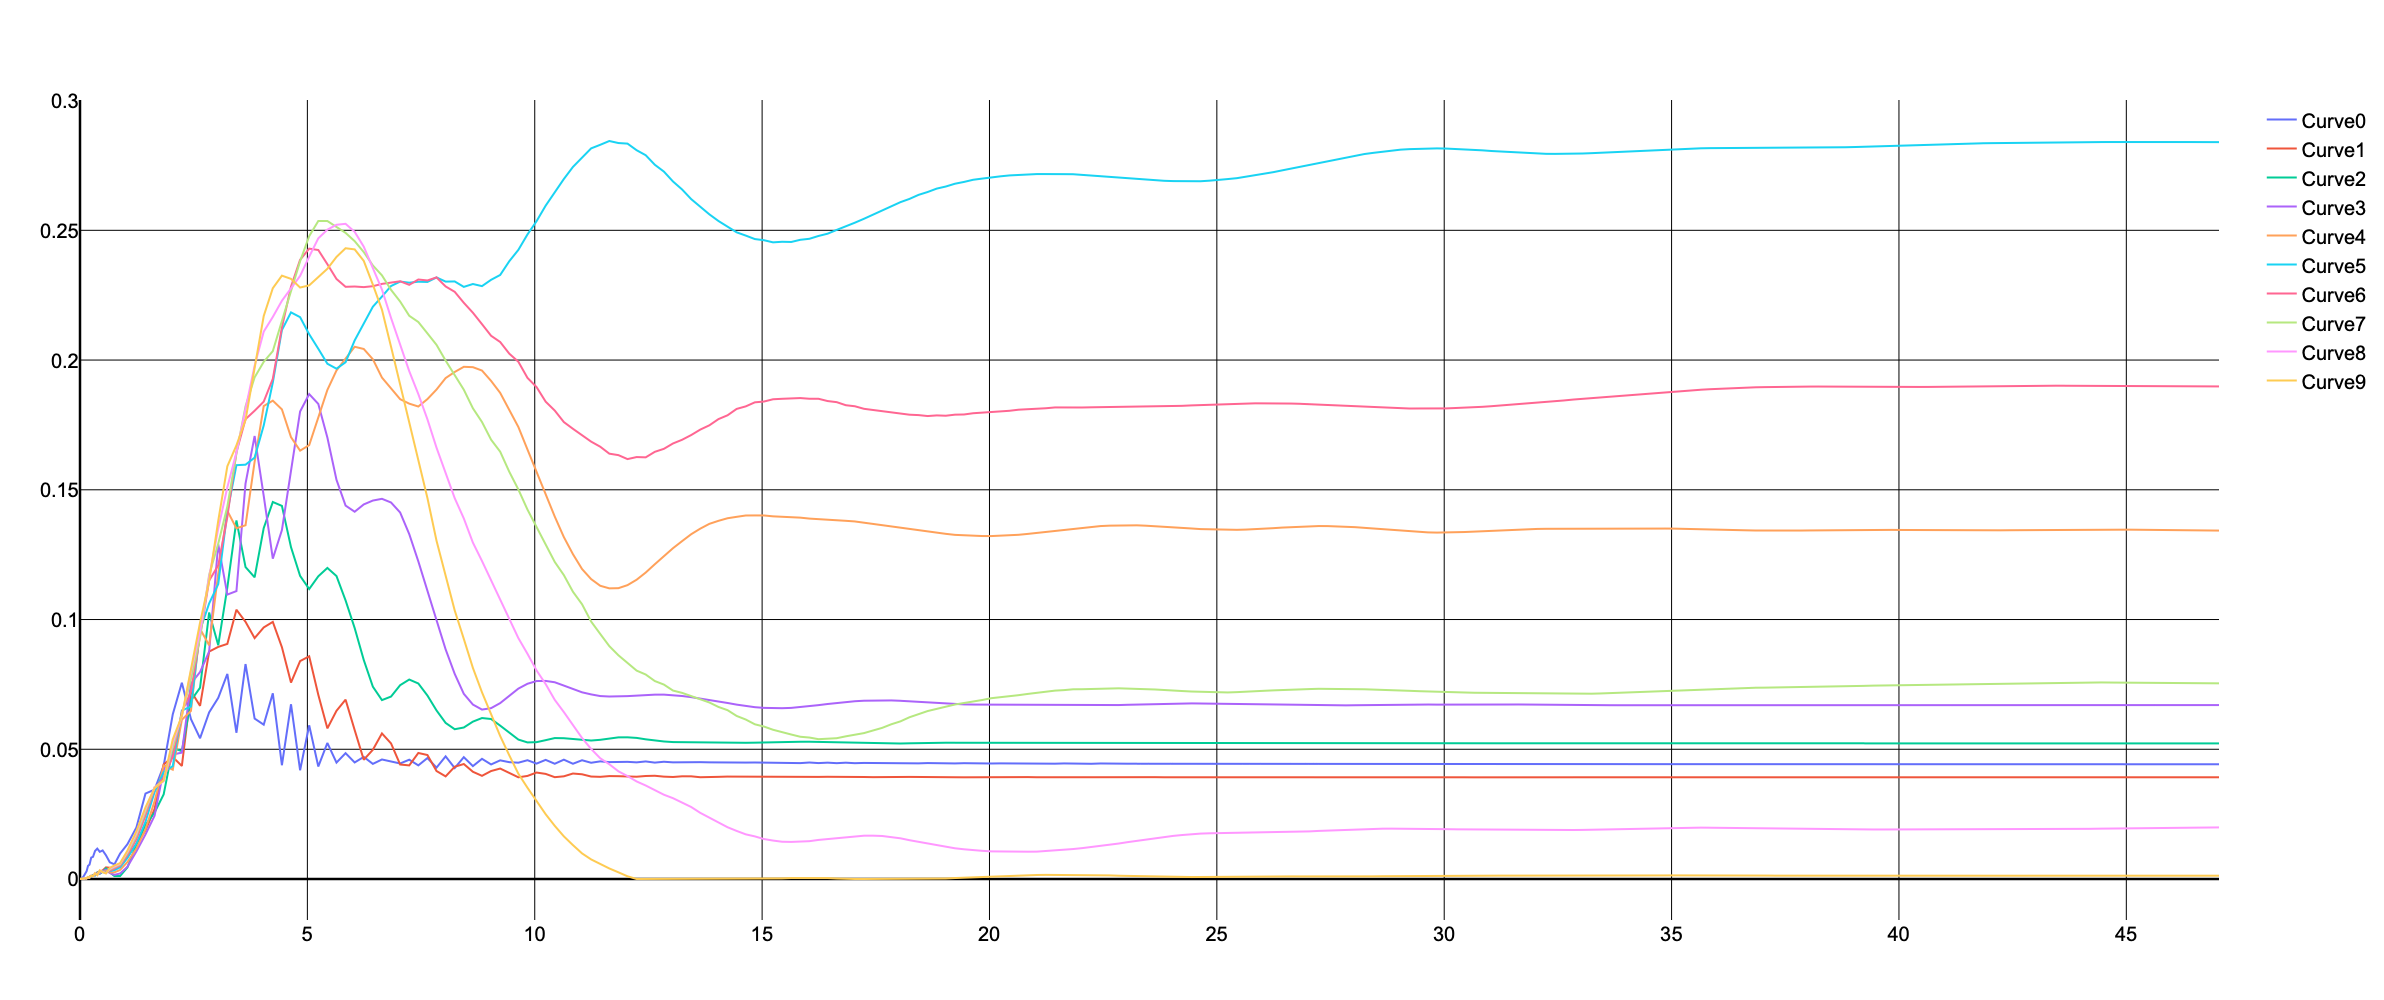

In [23]:
plt = PlotIt()
t = torch.arange(0, 5_000, step = 20)
S = O.oneBodyRenyiEntropy(t = t)
plt.extend_data(*(dict(x = O.dt.t[t], y = S[:,A] )for A in range(O.N)))
plt.show()

In [19]:
O.B(0)

tensor([[ 0.0000+0.j,  0.0000+0.j, 10.0000+0.j],
        [ 0.0000+0.j,  0.0000+0.j,  5.0000+0.j],
        [ 0.0000+0.j,  0.0000+0.j,  3.3333+0.j],
        [ 0.0000+0.j,  0.0000+0.j,  2.5000+0.j],
        [ 0.0000+0.j,  0.0000+0.j,  2.0000+0.j],
        [ 0.0000+0.j,  0.0000+0.j,  1.6667+0.j],
        [ 0.0000+0.j,  0.0000+0.j,  1.4286+0.j],
        [ 0.0000+0.j,  0.0000+0.j,  1.2500+0.j],
        [ 0.0000+0.j,  0.0000+0.j,  1.1111+0.j],
        [ 0.0000+0.j,  0.0000+0.j,  1.0000+0.j]], dtype=torch.complex128)

In [22]:
O

BBGKYDecoupling(N=10, n=2, method = fullrk)